In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load modeling dataset

model_data = pd.read_csv("../data/model_data.csv")

In [3]:
# Separate features and target variable

X = model_data.drop(columns=["price_clean"])
y = model_data["price_clean"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (21364, 73)
Target shape: (21364,)


In [6]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (17091, 73)
Testing set: (4273, 73)


In [7]:
# Train a linear regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](73,)","[ 46.8 , 27.32, -2.29,..., 30.74, 120.22,7766.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](73,)","['accommodates','bedrooms','beds',...,'property_type_Shared room in villa', 'property_type_Tiny home','property_type_Tower']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-260.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,73
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(71)


In [8]:
# Make predictions

y_pred = model.predict(X_test)

print(y_pred[:10])

[247.7688736  169.8230986  368.41589073 270.9849357  339.32068182
 399.00445296 317.2656983   50.9813739   52.85112151  45.01808398]


In [9]:
# Evaluate the model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R-squared:", round(r2, 3))

Mean Absolute Error: 158.56
Root Mean Squared Error: 406.48
R-squared: 0.138


In [10]:
# Train a random forest model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [11]:
# Evaluate the random forest model

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Mean Absolute Error:", round(rf_mae, 2))
print("Random Forest Root Mean Squared Error:", round(rf_rmse, 2))
print("Random Forest R-squared:", round(rf_r2, 3))

Random Forest Mean Absolute Error: 136.42
Random Forest Root Mean Squared Error: 374.52
Random Forest R-squared: 0.268


ValueError: x and y must be the same size

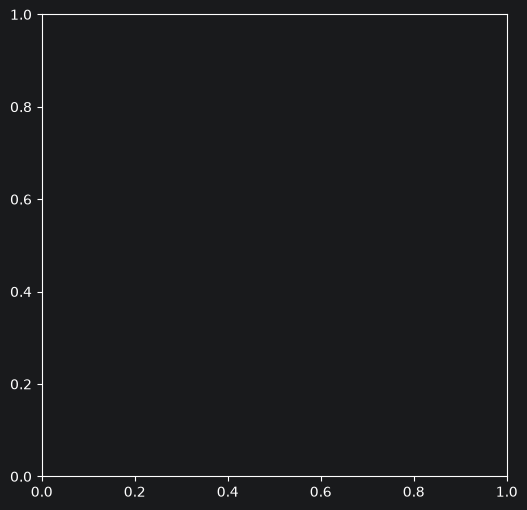

In [25]:
# Actual vs predicted prices

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")

plt.show()

In [13]:
# Remove luxury listings over $1,000
filtered_data = model_data[model_data["price_clean"] <= 1000]

print(filtered_data.shape)
filtered_data.head()

(20785, 74)


,accommodates,bedrooms,beds,bathrooms,review_scores_rating,number_of_reviews,availability_365,price_clean,room_type_Hotel room,room_type_Private room,...,property_type_Shared room in condo,property_type_Shared room in guest suite,property_type_Shared room in guesthouse,property_type_Shared room in home,property_type_Shared room in rental unit,property_type_Shared room in serviced apartment,property_type_Shared room in townhouse,property_type_Shared room in villa,property_type_Tiny home,property_type_Tower
0,2,1.0,2.0,1.0,4.80,10,339,113.97,False,True,...,False,False,False,False,False,False,False,False,False,False
1,3,2.0,1.0,1.0,4.60,198,191,117.27,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,0.0,1.0,1.0,5.00,2,286,80.06,False,True,...,False,False,False,False,False,False,False,False,False,False
3,1,0.0,1.0,1.0,4.88,251,218,77.17,False,True,...,False,False,False,False,False,False,False,False,False,False
4,2,0.0,2.0,1.0,4.89,423,106,202.47,False,True,...,False,False,False,False,False,False,False,False,False,False


In [14]:
X_filtered = filtered_data.drop(columns=["price_clean"])
y_filtered = filtered_data["price_clean"]

print(X_filtered.shape)
print(y_filtered.shape)

(20785, 73)
(20785,)


In [15]:
from sklearn.model_selection import train_test_split

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

linear_filtered = LinearRegression()

linear_filtered.fit(X_train_f, y_train_f)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](73,)","[ 21.09, 16.37, 8.93,..., 52.53,127.64, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](73,)","['accommodates','bedrooms','beds',...,'property_type_Shared room in villa', 'property_type_Tiny home','property_type_Tower']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-11.34
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,73
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(68)


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = linear_filtered.predict(X_test_f)

mae = mean_absolute_error(y_test_f, pred)
rmse = mean_squared_error(y_test_f, pred) ** 0.5
r2 = r2_score(y_test_f, pred)

print("Filtered Linear Regression")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

Filtered Linear Regression
MAE: 98.68
RMSE: 141.87
R²: 0.36


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_filtered = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_filtered.fit(X_train_f, y_train_f)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [19]:
rf_pred = rf_filtered.predict(X_test_f)

rf_mae = mean_absolute_error(y_test_f, rf_pred)
rf_rmse = mean_squared_error(y_test_f, rf_pred) ** 0.5
rf_r2 = r2_score(y_test_f, rf_pred)

print("Filtered Random Forest")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²:", round(rf_r2, 3))

Filtered Random Forest
MAE: 86.04
RMSE: 129.63
R²: 0.466


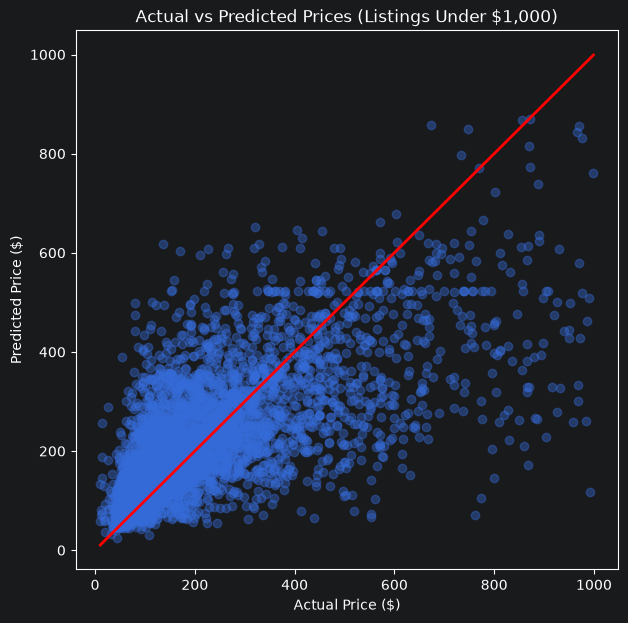

In [23]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test_f,
    rf_pred,
    alpha=0.4
)

plt.plot(
    [y_test_f.min(), y_test_f.max()],
    [y_test_f.min(), y_test_f.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Prices (Listings Under $1,000)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.savefig("../images/actual_vs_predicted_filtered.png", dpi=300, bbox_inches="tight")
plt.show()

## Model Comparison

Two sets of models were trained. The first used all Airbnb listings, including luxury properties priced above 1,000 dollars per night. Because these extreme values produced large prediction errors, a second set of models was trained after removing listings priced above 1,000 dollars.

The filtered models consistently outperformed the original models. The Random Forest model achieved the best overall performance with an MAE of 86.04, an RMSE of 129.63, and an R² of 0.466. This suggests that removing extreme outliers improves predictive accuracy and allows the model to better capture pricing patterns among typical Airbnb listings.

In [24]:
import os

print(os.path.exists("../images/actual_vs_predicted_filtered.png"))

True
